In [51]:
#Import and Load the Data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')


In [5]:
# load data
df = pd.read_excel('Dry_Beans_Dataset.xlsx')
# check the first few rows of the data
print(df.head())

    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0  28395    610.291       208.178117       173.888747      1.197191   
1  28734    638.018       200.524796       182.734419      1.097356   
2  29380    624.110       212.826130       175.931143      1.209713   
3  30008    645.884       210.557999       182.516516      1.153638   
4  30140    620.134       201.847882       190.279279      1.060798   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
0      0.549812       28715     190.141097  0.763923  0.988856   0.958027   
1      0.411785       29172     191.272750  0.783968  0.984986   0.887034   
2      0.562727       29690     193.410904  0.778113  0.989559   0.947849   
3      0.498616       30724     195.467062  0.782681  0.976696   0.903936   
4      0.333680       30417     195.896503  0.773098  0.990893   0.984877   

   Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  Class  
0     0.913358      0.007332  

In [31]:
df.shape

(13611, 17)

In [6]:
# checking info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  str    
dtypes: float64(14), int64(2

In [9]:
#checking describe
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Area,13611.0,53048.284549,29324.095717,20420.000000,36328.000000,44652.000000,61332.000000,254616.000000
Perimeter,13611.0,855.283459,214.289696,524.736000,703.523500,794.941000,977.213000,1985.370000
MajorAxisLength,13611.0,320.141867,85.694186,183.601165,253.303633,296.883367,376.495012,738.860153
MinorAxisLength,13611.0,202.270714,44.970091,122.512653,175.848170,192.431733,217.031741,460.198497
AspectRation,13611.0,1.583242,0.246678,1.024868,1.432307,1.551124,1.707109,2.430306
Eccentricity,13611.0,0.750895,0.092002,0.218951,0.715928,0.764441,0.810466,0.911423
ConvexArea,13611.0,53768.200206,29774.915817,20684.000000,36714.500000,45178.000000,62294.000000,263261.000000
EquivDiameter,13611.0,253.064220,59.177120,161.243764,215.068003,238.438026,279.446467,569.374358
Extent,13611.0,0.749733,0.049086,0.555315,0.718634,0.759859,0.786851,0.866195
Solidity,13611.0,0.987143,0.004660,0.919246,0.985670,0.988283,0.990013,0.994677


# Exploratory Data Analysis (EDA)

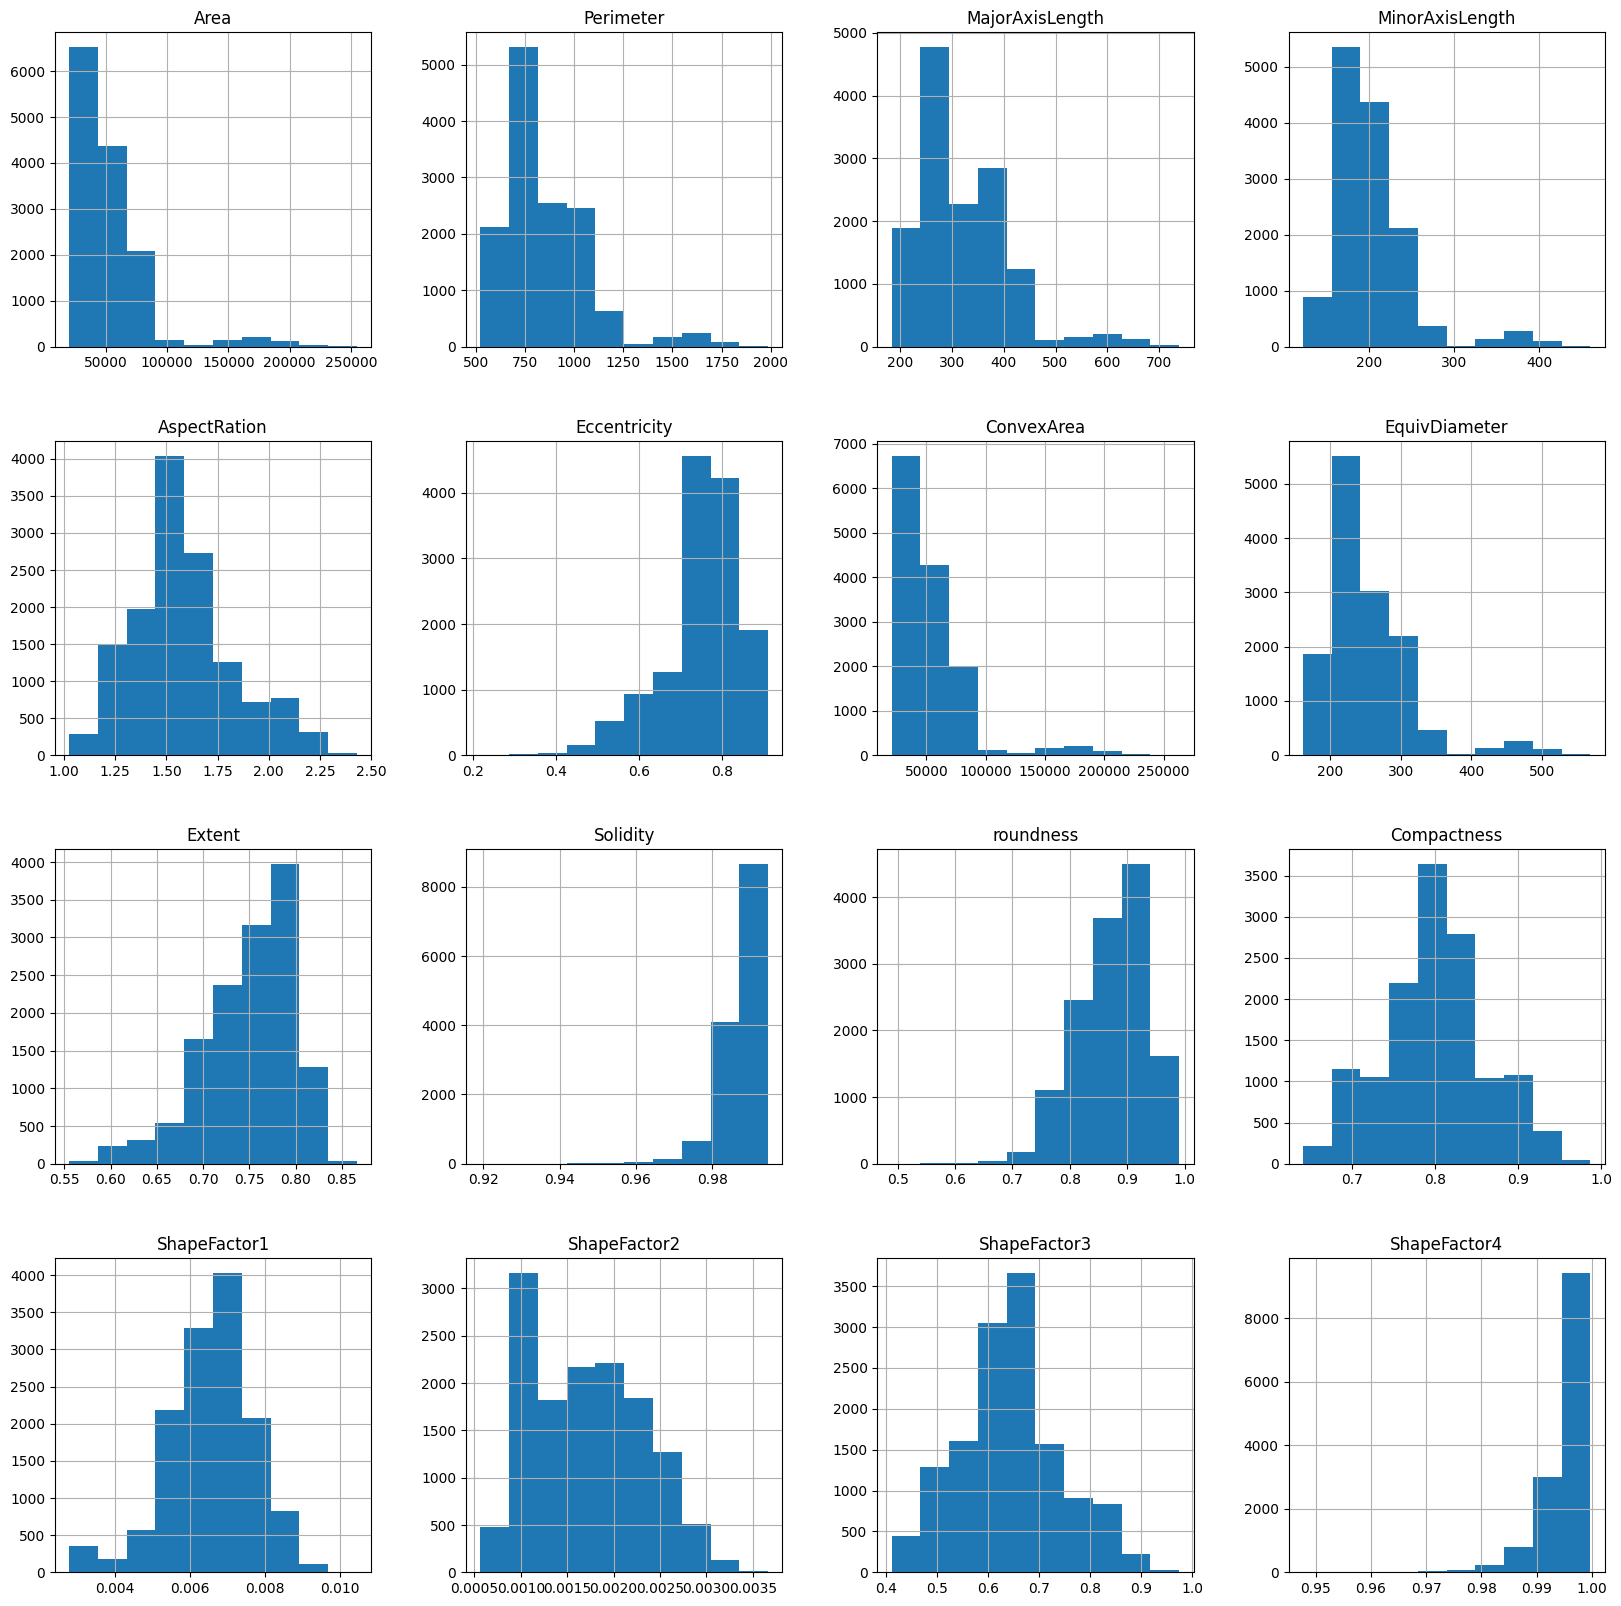

In [21]:
# checking distribution for each columns using histograms
df.hist(figsize=(20,20))
plt.show()

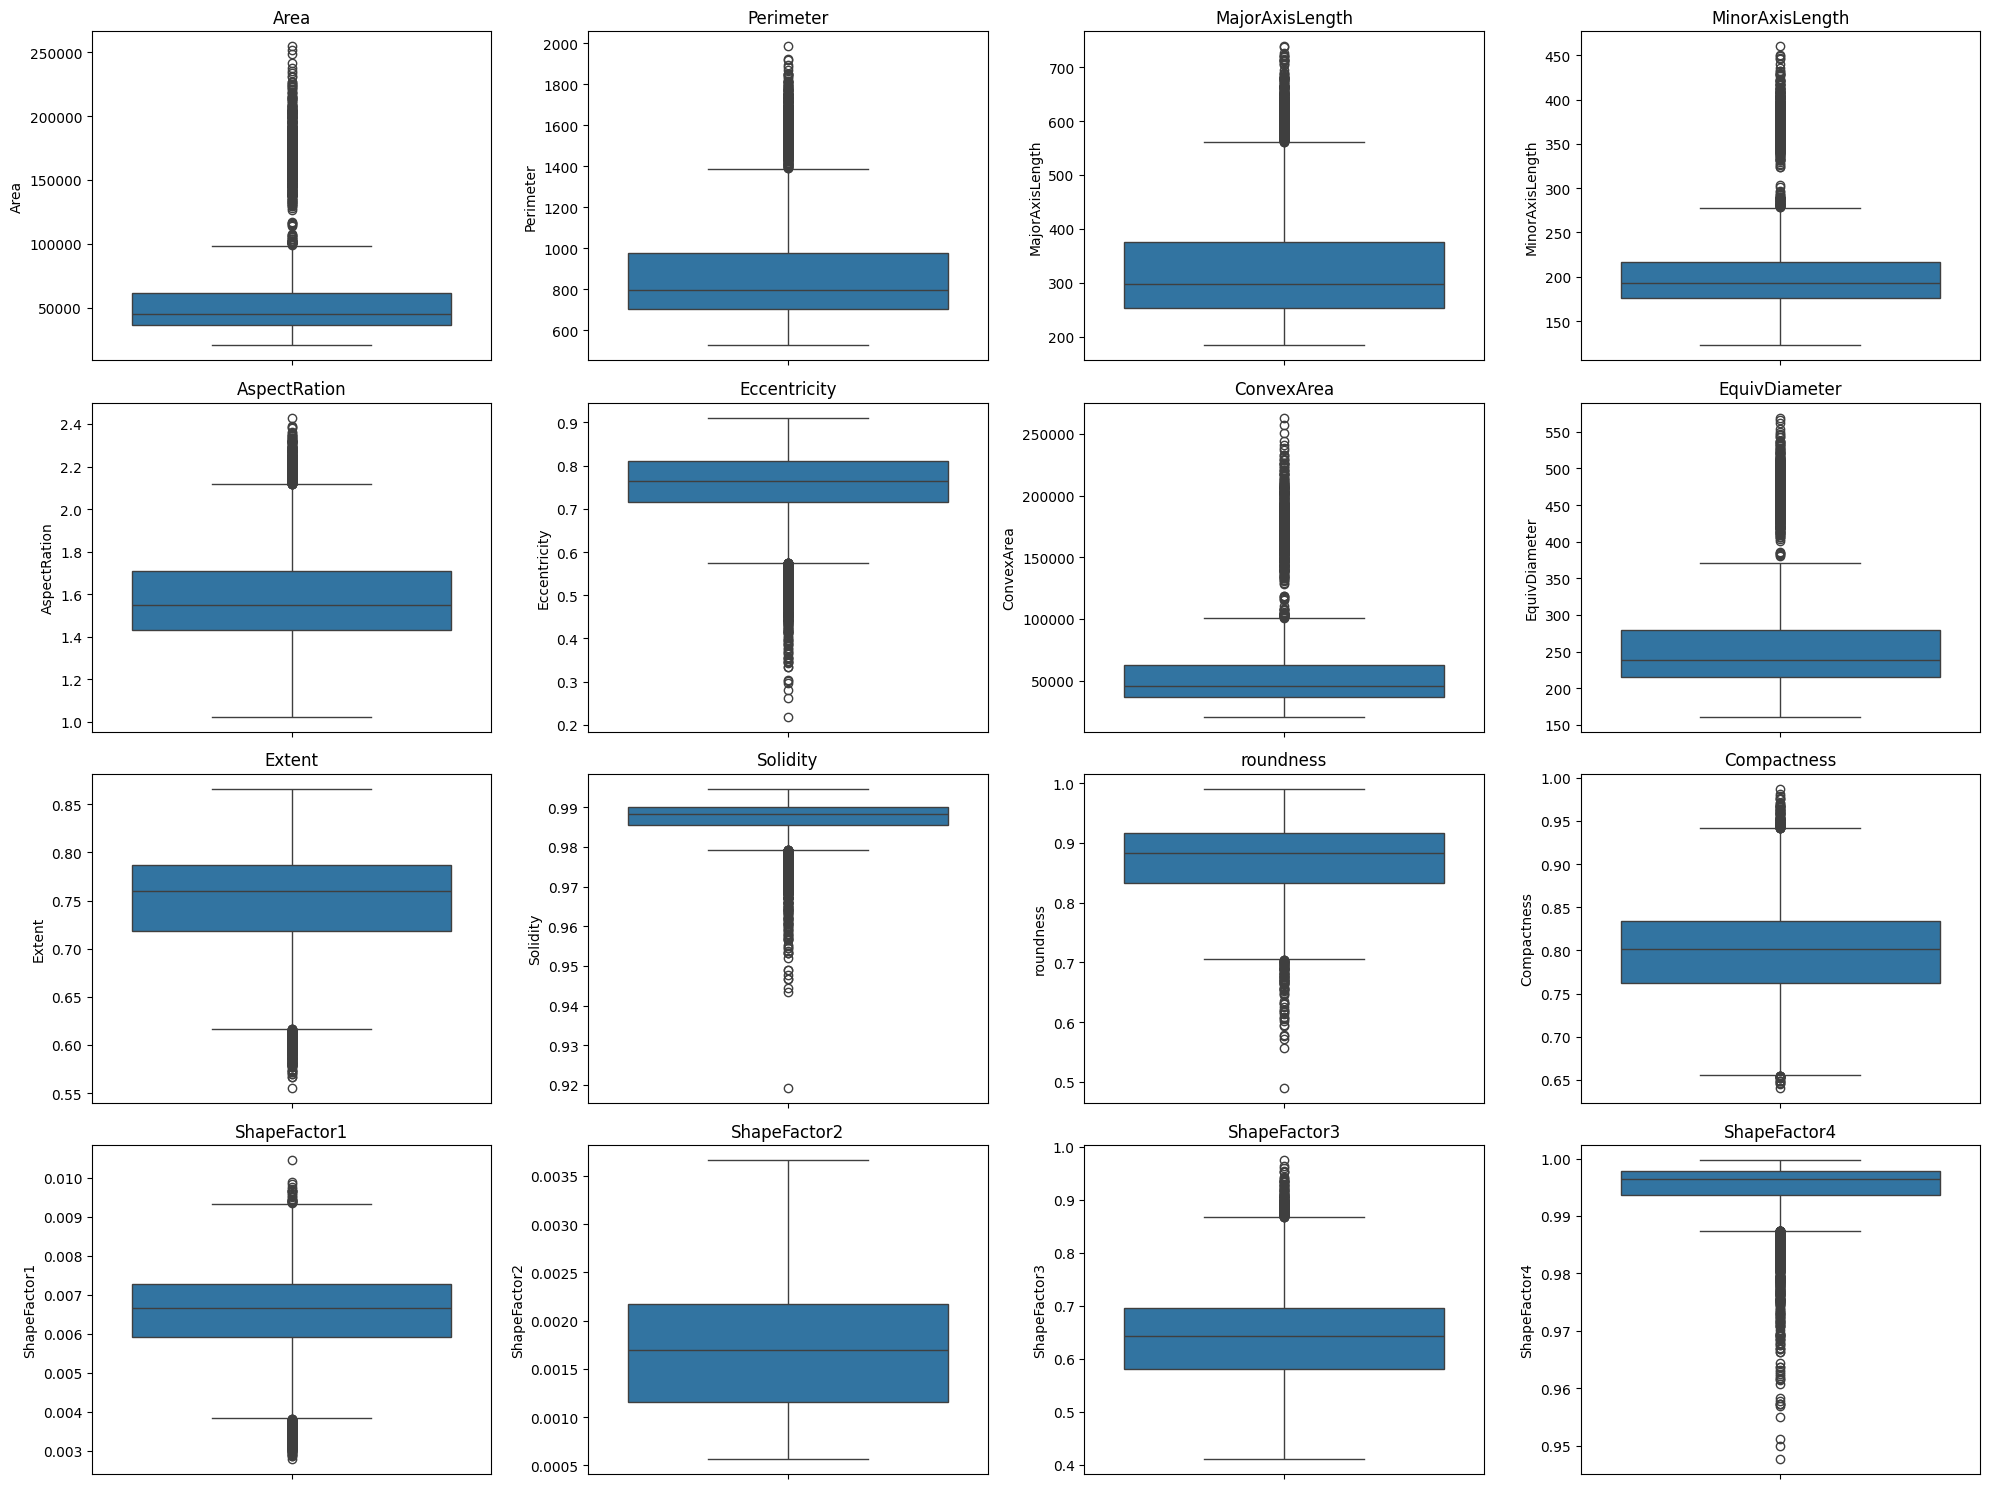

In [22]:
#Outlier Detection using Boxplots
plt.figure(figsize=(20,15))

for i, col in enumerate(df.select_dtypes(include=['int64','float64']).columns):
    plt.subplot(4,4,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

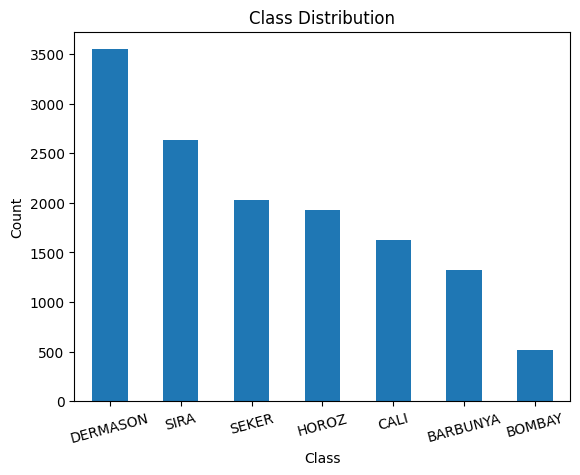

In [23]:
# Class Distribution
df['Class'].value_counts().plot(kind='bar',rot=15)
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [24]:
# categorical frequency distribution
df['Class'].value_counts()

Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

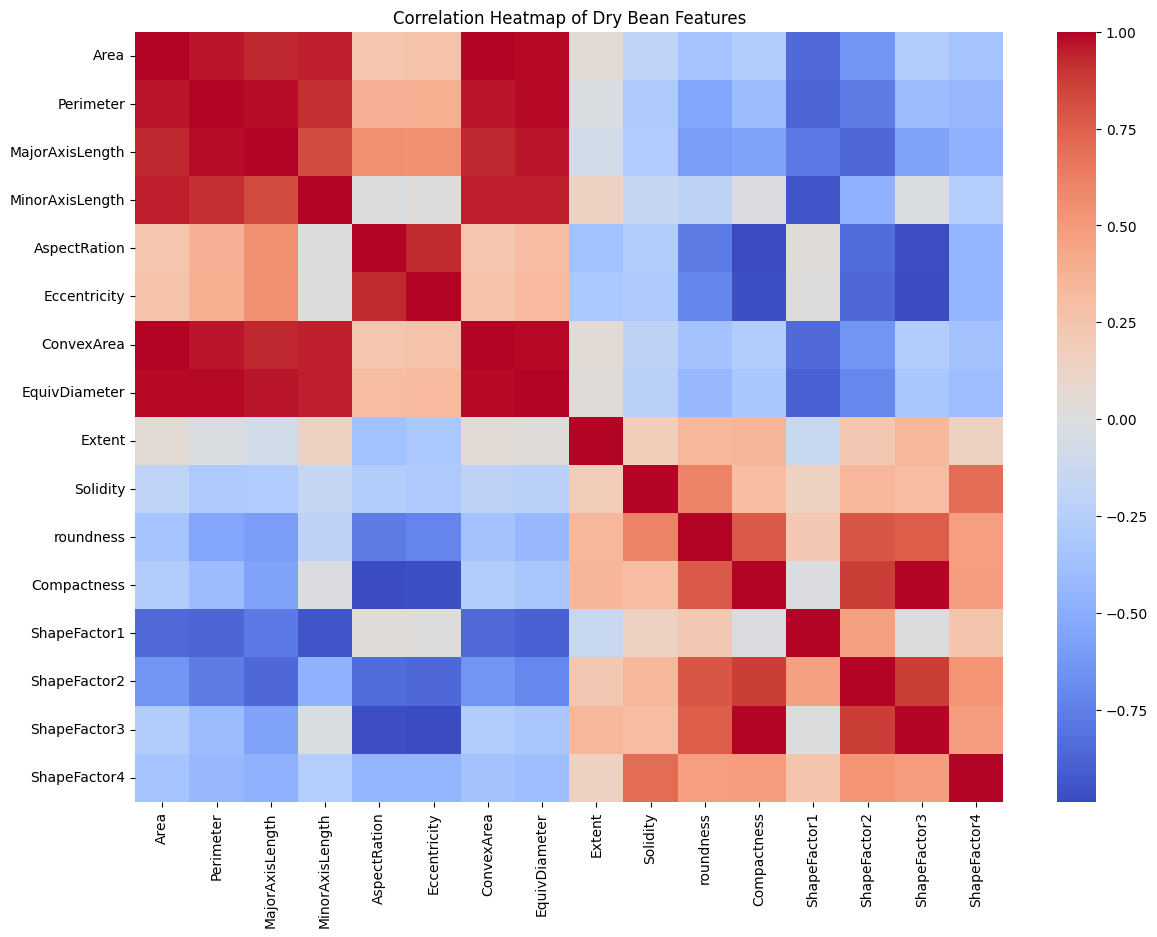

In [25]:
# Feature Correlation Heatmap
plt.figure(figsize=(14,10))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=False,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap of Dry Bean Features")
plt.show()

In [26]:
#Feature Correlation
df.corr(numeric_only=True).T

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
Area,1.000000,0.966722,0.931834,0.951602,0.241735,0.267481,0.999939,0.984968,0.054345,-0.196585,-0.357530,-0.268067,-0.847958,-0.639291,-0.272145,-0.355721
Perimeter,0.966722,1.000000,0.977338,0.913179,0.385276,0.391066,0.967689,0.991380,-0.021160,-0.303970,-0.547647,-0.406857,-0.864623,-0.767592,-0.408435,-0.429310
MajorAxisLength,0.931834,0.977338,1.000000,0.826052,0.550335,0.541972,0.932607,0.961733,-0.078062,-0.284302,-0.596358,-0.568377,-0.773609,-0.859238,-0.568185,-0.482527
MinorAxisLength,0.951602,0.913179,0.826052,1.000000,-0.009161,0.019574,0.951339,0.948539,0.145957,-0.155831,-0.210344,-0.015066,-0.947204,-0.471347,-0.019326,-0.263749
AspectRation,0.241735,0.385276,0.550335,-0.009161,1.000000,0.924293,0.243301,0.303647,-0.370184,-0.267754,-0.766979,-0.987687,0.024593,-0.837841,-0.978592,-0.449264
Eccentricity,0.267481,0.391066,0.541972,0.019574,0.924293,1.000000,0.269255,0.318667,-0.319362,-0.297592,-0.722272,-0.970313,0.019920,-0.860141,-0.981058,-0.449354
ConvexArea,0.999939,0.967689,0.932607,0.951339,0.243301,0.269255,1.000000,0.985226,0.052564,-0.206191,-0.362083,-0.269922,-0.847950,-0.640862,-0.274024,-0.362049
EquivDiameter,0.984968,0.991380,0.961733,0.948539,0.303647,0.318667,0.985226,1.000000,0.028383,-0.231648,-0.435945,-0.327650,-0.892741,-0.713069,-0.330389,-0.392512
Extent,0.054345,-0.021160,-0.078062,0.145957,-0.370184,-0.319362,0.052564,0.028383,1.000000,0.191389,0.344411,0.354212,-0.141616,0.237956,0.347624,0.148502
Solidity,-0.196585,-0.303970,-0.284302,-0.155831,-0.267754,-0.297592,-0.206191,-0.231648,0.191389,1.000000,0.607150,0.303766,0.153388,0.343559,0.307662,0.702163


#### Statistical Summary

- Feature values show considerable variation across bean types.
- Some features have a wide range of values, indicating differences in bean size and shape.
- Initial statistics suggest the presence of potential outliers.

#### Missing Values Analysis

- No missing values were found in the dataset.
- All 13,611 records contain complete information.
- Missing value treatment is not required.


#### Data Types

- The dataset contains 14 float features and 2 integer features.
- The target variable (Class) is categorical.
- All columns have appropriate data types for analysis.

#### Dataset Overview

- The dataset contains 13,611 records and 17 columns.
- There are 16 feature columns and 1 target column (Class).
- Most features are numerical and represent bean shape and size characteristics.

#### Histogram Analysis

- Several features exhibit skewed distributions.
- Area, ConvexArea, and EquivDiameter show right-skewness.
- Most shape-related features are approximately normally distributed.
- Outlier investigation is recommended.

#### Class Distribution

- The dataset contains seven bean classes.
- DERMASON is the most frequent class.
- BOMBAY is the least frequent class.
- A moderate class imbalance is present.

#### Outlier Analysis

- Outliers are present in multiple numerical features.
- Size-related features show a larger number of extreme observations.
- Most outliers appear to be genuine observations rather than data errors.
- Further evaluation is required before removing outliers.


#### Correlation Analysis Summary

- Strong positive correlations exist among Area, ConvexArea, EquivDiameter, Perimeter, and MajorAxisLength.
- AspectRatio and Eccentricity show a high positive correlation.
- Compactness and ShapeFactor3 are almost perfectly correlated.
- Strong negative correlations are observed between Compactness and AspectRatio, and between ShapeFactor3 and Eccentricity.
- The dataset exhibits multicollinearity among several features.
- Feature removal is not required at this stage; further analysis and model evaluation will be performed.

# Missing Values & Outlier Treatment


In [27]:
df.isnull().sum()

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

#### Missing Values Analysis

- No missing values were found in the dataset.
- All features contain complete records.
- Missing value treatment is not required.

In [28]:
# checling for duplicates
df.duplicated().sum()

np.int64(68)

In [30]:
#Check Duplicate Rows
duplicate_rows = df[df.duplicated()]

duplicate_rows.sample(68)

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
6307,52313,896.732,352.482089,189.300951,1.862020,0.843550,53085,258.083282,0.785198,0.985457,0.817512,0.732188,0.006738,0.001195,0.536100,0.998228,HOROZ
7340,65766,1035.842,406.416622,207.242369,1.961069,0.860218,66698,289.371512,0.792295,0.986027,0.770237,0.712007,0.006180,0.000980,0.506954,0.994172,HOROZ
5756,45478,838.042,331.843270,176.276767,1.882513,0.847243,46206,240.633306,0.608011,0.984244,0.813729,0.725141,0.007297,0.001245,0.525830,0.989882,HOROZ
6983,59105,957.363,372.981361,205.545240,1.814595,0.834448,60667,274.326126,0.757630,0.974253,0.810365,0.735496,0.006310,0.001139,0.540954,0.981612,HOROZ
6515,54187,919.972,372.954622,186.450123,2.000292,0.866067,54828,262.665246,0.759241,0.988309,0.804555,0.704282,0.006883,0.001045,0.496013,0.992171,HOROZ
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7278,63882,1004.206,411.263403,198.765453,2.069089,0.875452,64663,285.196579,0.754705,0.987922,0.796054,0.693465,0.006438,0.000918,0.480893,0.995010,HOROZ
6220,51515,896.279,375.980183,174.907355,2.149596,0.885204,52000,256.107273,0.804294,0.990673,0.805855,0.681172,0.007298,0.000969,0.463996,0.997403,HOROZ
7263,63408,1005.966,412.551649,196.337705,2.101235,0.879494,64200,284.136539,0.798791,0.987664,0.787385,0.688730,0.006506,0.000903,0.474348,0.996718,HOROZ
6750,56413,929.481,377.880838,191.039673,1.978023,0.862794,57007,268.006087,0.661240,0.989580,0.820556,0.709234,0.006698,0.001045,0.503013,0.994972,HOROZ


In [32]:
#Remove Duplicates
df = df.drop_duplicates()

In [33]:
#Verify Removal
print("Duplicate Rows:", df.duplicated().sum())
print("Dataset Shape:", df.shape)

Duplicate Rows: 0
Dataset Shape: (13543, 17)


#### Duplicate Records Analysis

- The dataset contained 68 duplicate records.
- Duplicate rows were identified using the duplicated() function.
- These duplicate observations were removed to avoid bias during model training.
- The dataset was updated before proceeding with further preprocessing and analysis.

In [35]:
# checking skewness
df.skew(numeric_only=True)

Area               2.947136
Perimeter          1.628018
MajorAxisLength    1.365813
MinorAxisLength    2.232013
AspectRation       0.589045
Eccentricity      -1.064932
ConvexArea         2.936102
EquivDiameter      1.947303
Extent            -0.895655
Solidity          -2.546877
roundness         -0.648725
Compactness        0.036309
ShapeFactor1      -0.530427
ShapeFactor2       0.294332
ShapeFactor3       0.242767
ShapeFactor4      -2.760125
dtype: float64

| Skewness Value | Interpretation       | Action                     |
| -------------- | -------------------- | -------------------------- |
| -0.5 to 0.5    | Approximately Normal | No transformation          |
| 0.5 to 1       | Moderate Skew        | Consider transformation    |
| > 1            | Highly Skewed        | Transformation recommended |
| < -1           | Highly Negative Skew | Consider Power Transform   |


# Highly Positively Skewed (>1)
- Area              2.95

- Perimeter         1.63

- MajorAxisLength   1.37

- MinorAxisLength   2.23

- ConvexArea        2.94

- EquivDiameter     1.95


* Recommended:

* Log Transformation

# Moderately Skewed
- AspectRatio   0.59

* Can leave as-is.

# Highly Negatively Skewed
- Eccentricity   -1.06
- Solidity       -2.55
- ShapeFactor4   -2.76

* Recommended:

* Power Transformation (Yeo-Johnson)

In [36]:
#Log Transformation

#Use for positive skewed features.

import numpy as np

log_columns = [
    'Area',
    'Perimeter',
    'MajorAxisLength',
    'MinorAxisLength',
    'ConvexArea',
    'EquivDiameter'
]

for col in log_columns:
    df[col] = np.log1p(df[col])

In [37]:
df[log_columns].skew()

Area               1.073117
Perimeter          0.848386
MajorAxisLength    0.640138
MinorAxisLength    1.307883
ConvexArea         1.067860
EquivDiameter      1.075826
dtype: float64

In [38]:
#Yeo-Johnson Transformation

#This is what many experienced analysts use.

from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')

transform_cols = [
    'Eccentricity',
    'Solidity',
    'ShapeFactor4'
]

df[transform_cols] = pt.fit_transform(df[transform_cols])

In [39]:
df[transform_cols].skew()

Eccentricity   -0.060854
Solidity       -0.962120
ShapeFactor4   -1.290740
dtype: float64

In [40]:
#Box-Cox

#Only for strictly positive values.

from scipy.stats import boxcox

df['Area_boxcox'], _ = boxcox(df['Area'])

In [42]:
df['Area_boxcox'].skew()

np.float64(0.02340899682628197)

In [43]:
df.drop('Area_boxcox', axis=1, inplace=True)

In [44]:
df.columns

Index(['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
       'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent',
       'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
       'ShapeFactor3', 'ShapeFactor4', 'Class'],
      dtype='str')

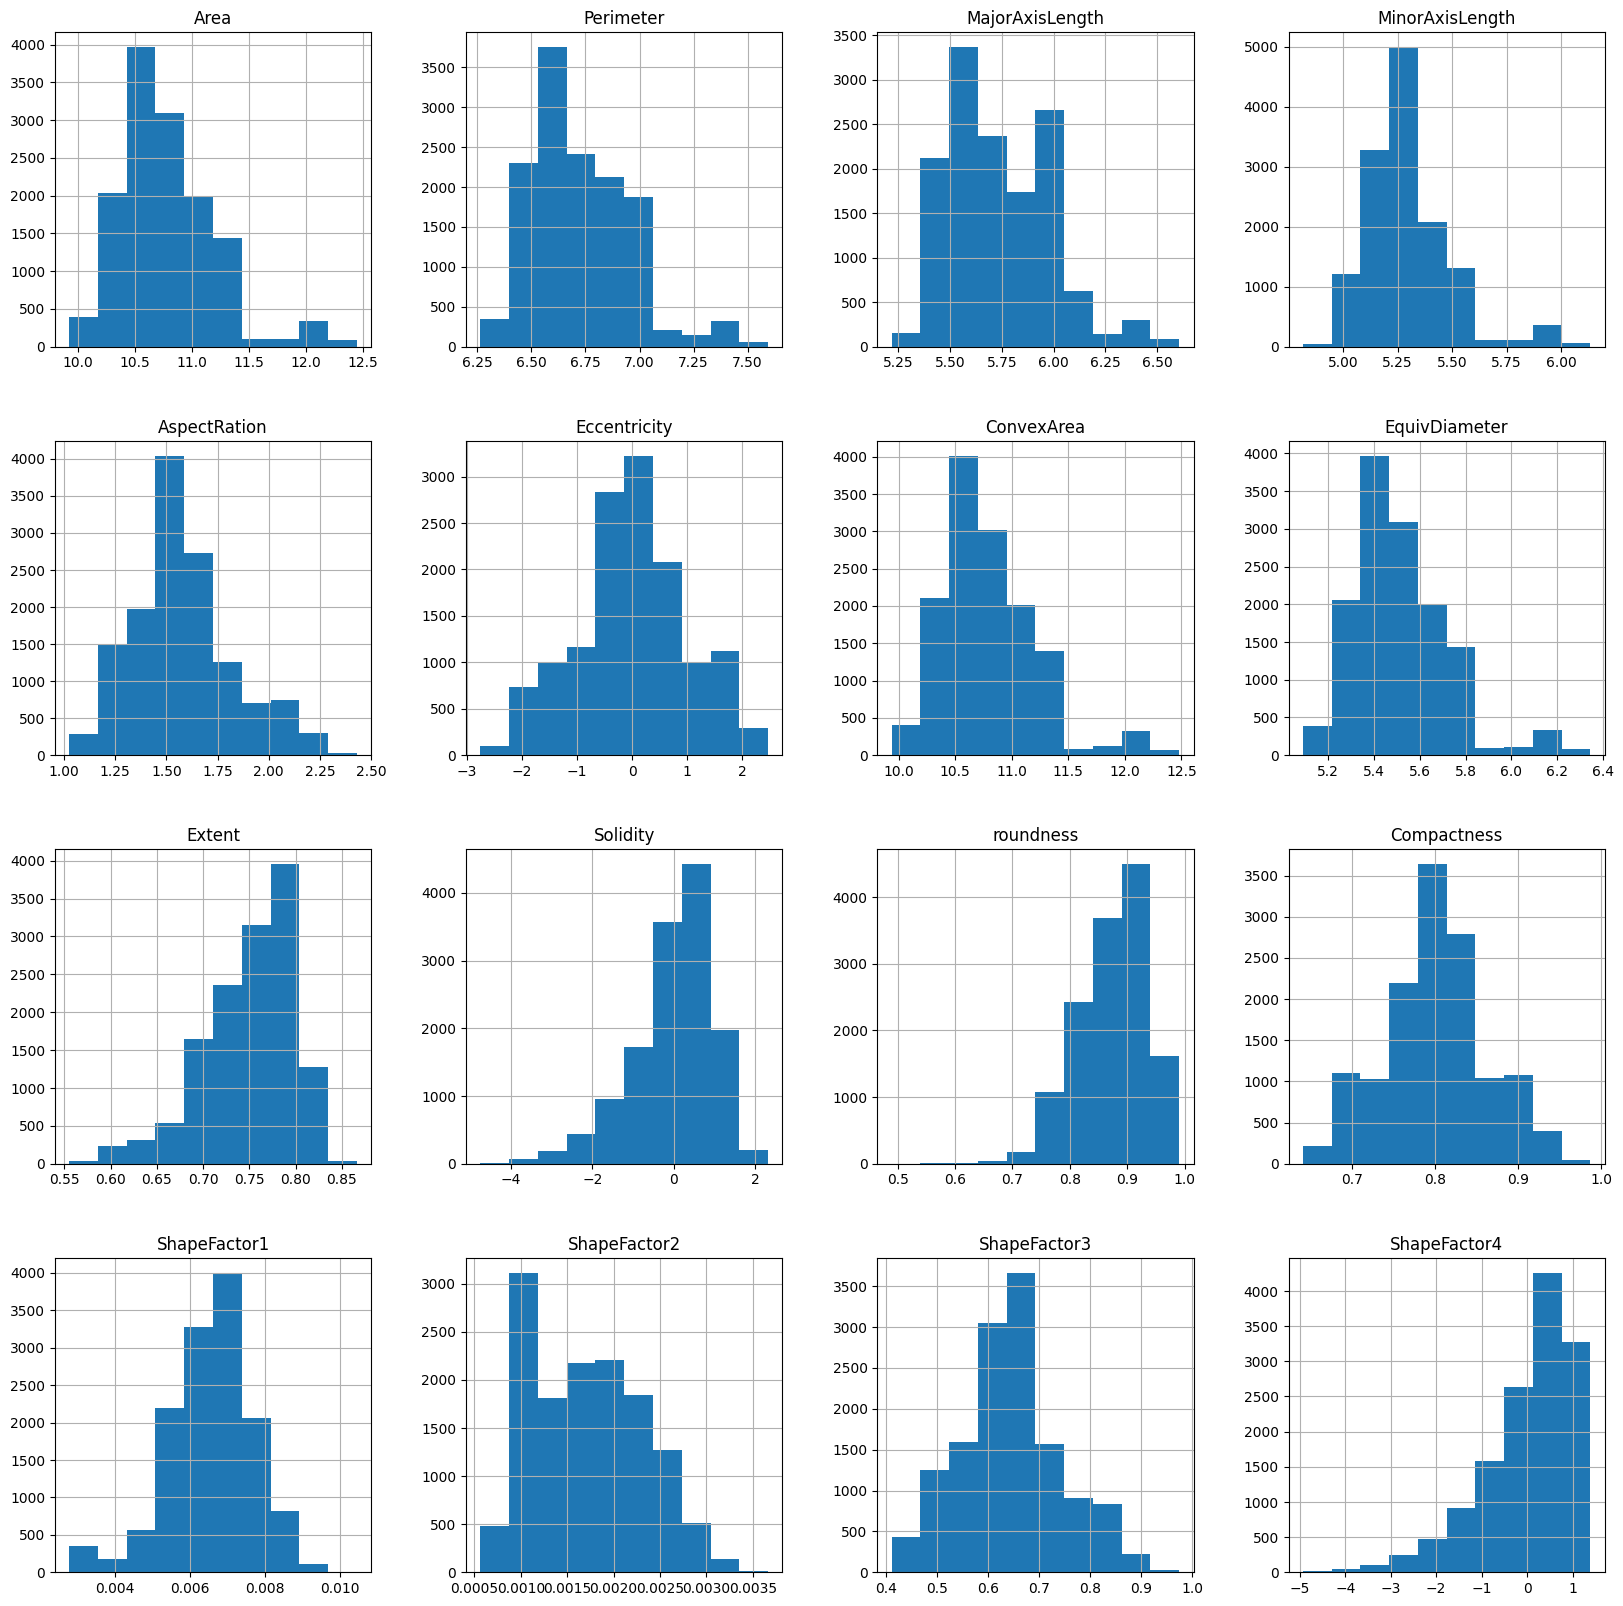

In [45]:
df.hist(figsize=(20,20))
plt.show()

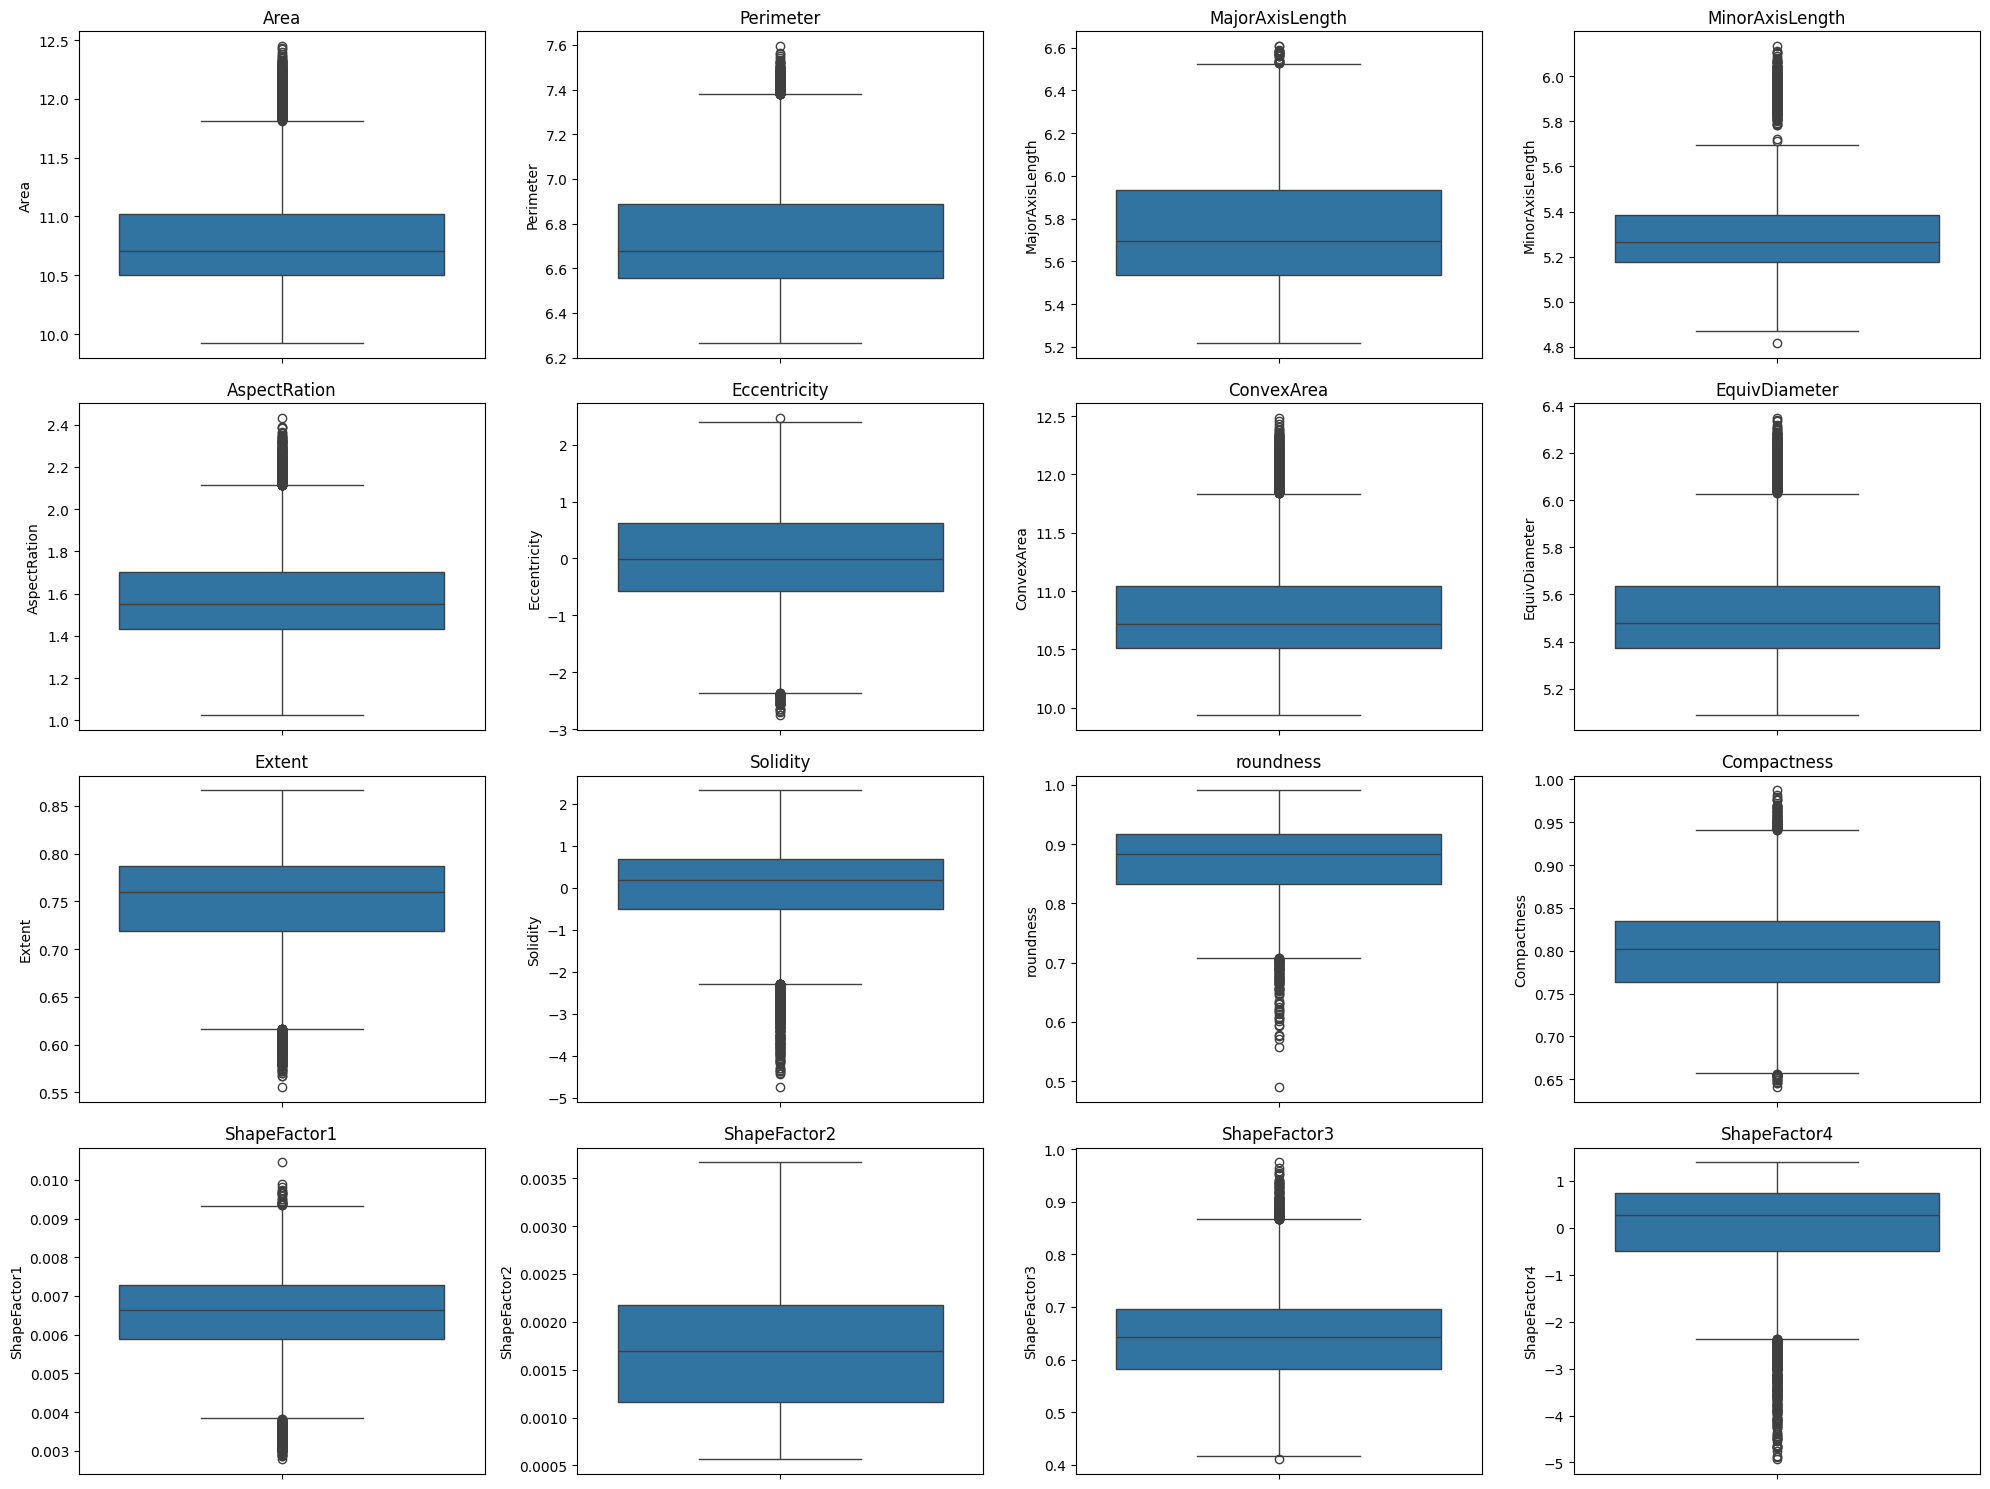

In [53]:
#Outlier Detection using Boxplots
plt.figure(figsize=(20,15))

for i, col in enumerate(df.select_dtypes(include=['int64','float64']).columns):
    plt.subplot(4,4,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

#### Outlier Treatment

- Outliers were identified using boxplots and skewness analysis.
- Log Transformation and Yeo-Johnson Transformation were applied to reduce skewness and minimize the impact of extreme values.
- The transformed features showed improved distributions and reduced skewness.
- Outliers were retained as they may represent genuine variations among different bean classes.

# Feature Engineering & Preprocessing

In [54]:
#Separate Features and Target
# Features and Target

X = df.drop('Class', axis=1)

y = df['Class']

print(X.shape)
print(y.shape)

(13543, 16)
(13543,)


In [55]:
# Encode Target Variable

#Since Class contains text labels:

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

print(le.classes_)

['BARBUNYA' 'BOMBAY' 'CALI' 'DERMASON' 'HOROZ' 'SEKER' 'SIRA']


In [56]:
#Train Test Split (Stratified)

#Very important because your dataset has class imbalance.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    
    X,
    y,
    
    test_size=0.2,
    
    random_state=42,
    
    stratify=y
    
)

print(X_train.shape)
print(X_test.shape)

(10834, 16)
(2709, 16)


In [57]:
#Feature Scaling

#I will use:

#Logistic Regression
#KNN
#SVM

#Scaling is recommended.

#Use StandardScaler:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [60]:
#Verify Scaling
print(X_train_scaled)
print(X_test_scaled)

[[ 0.89773263  1.11789858  1.03197091 ... -1.05229433 -0.90313245
  -2.33888007]
 [ 1.32650463  1.48858836  0.95685656 ... -0.57423887  0.43516216
  -0.31719721]
 [ 0.73765268  0.92177602  1.23240866 ... -1.40447671 -1.75538346
  -0.70909888]
 ...
 [-0.55012286 -0.60857277 -0.66475135 ...  0.63677631  0.60033368
   1.16173131]
 [ 0.89906146  1.02211124  0.76520932 ... -0.65355495 -0.11281708
  -0.39231663]
 [-1.27799887 -1.30052289 -1.14163045 ...  0.82394201  0.14922239
   0.91693284]]
[[-0.41279475 -0.53502397 -0.90382523 ...  1.55931041  1.95524578
   0.33960084]
 [-0.99430313 -1.02510997 -0.86763959 ...  0.5212499   0.03115292
   0.67647915]
 [-0.90329512 -0.9502735  -0.96121988 ...  0.90371132  0.60212224
   0.14609024]
 ...
 [-0.52103827 -0.73790779 -0.94770217 ...  1.50531987  1.76229452
   0.9420014 ]
 [ 0.21848465 -0.00469687 -0.17771933 ...  0.49078046  1.17290234
   0.80189776]
 [ 0.0536059  -0.03759675 -0.15469593 ...  0.21625333  0.58652521
   0.60573472]]


#### Feature Engineering & Preprocessing

- The target variable was encoded using LabelEncoder.
- The dataset was split into training and testing sets using stratified sampling.
- StandardScaler was applied to standardize numerical features.
- Feature scaling was performed to improve the performance of distance-based and linear machine learning algorithms.

In [62]:
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,10.254004,6.415573,5.343186,5.164150,1.197191,-1.841784,10.265210,5.253012,0.763923,0.337235,0.958027,0.913358,0.007332,0.003147,0.834222,1.032137,SEKER
1,10.265871,6.459933,5.305912,5.213491,1.097356,-2.395254,10.280999,5.258915,0.783968,-0.670106,0.887034,0.953861,0.006979,0.003564,0.909851,0.930156,SEKER
2,10.288103,6.437928,5.365163,5.175761,1.209713,-1.770699,10.298599,5.269974,0.778113,0.544396,0.947849,0.908774,0.007244,0.003048,0.825871,1.153125,SEKER
3,10.309253,6.472167,5.354499,5.212305,1.153638,-2.087600,10.332832,5.280495,0.782681,-2.221567,0.903936,0.928329,0.007017,0.003215,0.861794,-0.371030,SEKER
4,10.313642,6.431547,5.312456,5.253735,1.060798,-2.583013,10.322790,5.282678,0.773098,0.960585,0.984877,0.970516,0.006697,0.003665,0.941900,1.188879,SEKER


In [63]:
y

array([5, 5, 5, ..., 3, 3, 3], shape=(13543,))

In [65]:
X

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
0,10.254004,6.415573,5.343186,5.164150,1.197191,-1.841784,10.265210,5.253012,0.763923,0.337235,0.958027,0.913358,0.007332,0.003147,0.834222,1.032137
1,10.265871,6.459933,5.305912,5.213491,1.097356,-2.395254,10.280999,5.258915,0.783968,-0.670106,0.887034,0.953861,0.006979,0.003564,0.909851,0.930156
2,10.288103,6.437928,5.365163,5.175761,1.209713,-1.770699,10.298599,5.269974,0.778113,0.544396,0.947849,0.908774,0.007244,0.003048,0.825871,1.153125
3,10.309253,6.472167,5.354499,5.212305,1.153638,-2.087600,10.332832,5.280495,0.782681,-2.221567,0.903936,0.928329,0.007017,0.003215,0.861794,-0.371030
4,10.313642,6.431547,5.312456,5.253735,1.060798,-2.583013,10.322790,5.282678,0.773098,0.960585,0.984877,0.970516,0.006697,0.003665,0.941900,1.188879
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13606,10.647756,6.634234,5.668921,5.230813,1.552728,0.004736,10.657471,5.448958,0.714574,0.781563,0.916603,0.801865,0.006858,0.001749,0.642988,0.914639
13607,10.647851,6.631341,5.643949,5.256000,1.476439,-0.347333,10.657142,5.449005,0.799943,0.914951,0.922015,0.822252,0.006688,0.001886,0.676099,0.857632
13608,10.648753,6.633741,5.643820,5.258474,1.472582,-0.365874,10.658905,5.449455,0.729932,0.647534,0.918424,0.822730,0.006681,0.001888,0.676884,0.382429
13609,10.648943,6.639587,5.650321,5.253716,1.489326,-0.285908,10.661205,5.449549,0.705389,0.044123,0.907906,0.817457,0.006724,0.001852,0.668237,-0.083440


## Logistic Regression

Logistic Regression is a linear classification algorithm that predicts the probability of each bean class.

In [66]:
#Import
from sklearn.linear_model import LogisticRegression
#Create Model Object
lr_model = LogisticRegression(
    
    max_iter=500,
    
    random_state=42
    
)

In [67]:
#Train Model

#Since Logistic Regression needs scaled data:

lr_model.fit(
    
    X_train_scaled,
    
    y_train
    
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",500
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbf

In [68]:
#Prediction
y_pred_lr = lr_model.predict(
    
    X_test_scaled
)

In [69]:
#Accuracy
from sklearn.metrics import accuracy_score

accuracy_score(
    
    y_test,
    
    y_pred_lr
    
)
#Classification Report
from sklearn.metrics import classification_report

print(
    
    classification_report(
        
        y_test,
        
        y_pred_lr
        
    )
)

              precision    recall  f1-score   support

           0       0.93      0.89      0.91       265
           1       1.00      1.00      1.00       104
           2       0.91      0.94      0.93       326
           3       0.93      0.91      0.92       709
           4       0.96      0.94      0.95       372
           5       0.93      0.95      0.94       406
           6       0.86      0.89      0.88       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



In [70]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

confusion_matrix(
    
    y_test,
    
    y_pred_lr
)

array([[237,   0,  18,   0,   0,   4,   6],
       [  0, 104,   0,   0,   0,   0,   0],
       [  9,   0, 308,   0,   5,   2,   2],
       [  0,   0,   0, 644,   0,  12,  53],
       [  1,   0,  11,   5, 351,   0,   4],
       [  8,   0,   0,   5,   0, 384,   9],
       [  1,   0,   0,  39,   8,   9, 470]])

## K-Nearest Neighbors (KNN)

KNN classifies a bean based on the nearest neighboring observations.

In [71]:
#Import
from sklearn.neighbors import KNeighborsClassifier
#Create Model
knn_model = KNeighborsClassifier(
    
    n_neighbors=5
    
)

In [72]:
#Train
knn_model.fit(
    
    X_train_scaled,
    
    y_train
)
#Predict
y_pred_knn = knn_model.predict(
    
    X_test_scaled
)

In [73]:
#Evaluate
from sklearn.metrics import accuracy_score

accuracy_score(
    
    y_test,
    
    y_pred_knn
)

0.9106681432262828

## Support Vector Machine (SVM)

SVM finds the optimal boundary that separates bean classes.

In [74]:
#Import
from sklearn.svm import SVC
#Create Model
svm_model = SVC(
    
    kernel='rbf',
    
    random_state=42
    
)

In [75]:
#Train
svm_model.fit(
    
    X_train_scaled,
    
    y_train
)
#Predict
y_pred_svm = svm_model.predict(
    
    X_test_scaled
)

In [76]:
#Evaluate
from sklearn.metrics import accuracy_score

accuracy_score(
    
    y_test,
    
    y_pred_svm
)

0.9235880398671097

# Logistic Regression Cross Validation


In [77]:
#Import
from sklearn.model_selection import cross_val_score
#Cross Validation
lr_cv = cross_val_score(
    
    lr_model,
    
    X_train_scaled,
    
    y_train,
    
    cv=5,
    
    scoring='accuracy'
)

print("Cross Validation Scores:")
print(lr_cv)

print("\nMean CV Accuracy:")
print(lr_cv.mean())

Cross Validation Scores:
[0.92801108 0.92293493 0.9247808  0.92570374 0.92797784]

Mean CV Accuracy:
0.925881677696293


In [78]:
# Logistic Regression Tuning
# Import
from sklearn.model_selection import GridSearchCV
#Parameter Grid
lr_params = {
    
    'C':[0.01,0.1,1,10,100]
    
}

In [79]:
#Grid Search
lr_grid = GridSearchCV(
    
    LogisticRegression(max_iter=500),
    
    param_grid=lr_params,
    
    cv=5,
    
    scoring='accuracy'
)

lr_grid.fit(
    
    X_train_scaled,
    
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...(max_iter=500)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with 

In [80]:
print("Best Parameters:")
print(lr_grid.best_params_)

print("\nBest Score:")
print(lr_grid.best_score_)

Best Parameters:
{'C': 100}

Best Score:
0.9264354812662532


# KNN Cross Validation

In [81]:
knn_cv = cross_val_score(
    
    knn_model,
    
    X_train_scaled,
    
    y_train,
    
    cv=5,
    
    scoring='accuracy'
)

print("Cross Validation Scores:")
print(knn_cv)

print("\nMean CV Accuracy:")
print(knn_cv.mean())

Cross Validation Scores:
[0.91785879 0.922012   0.91878173 0.91924319 0.92243767]

Mean CV Accuracy:
0.9200666762965511


In [82]:
#KNN Tuning
#Parameters
knn_params = {
    
    'n_neighbors':[3,5,7,9,11]
    
}

In [83]:
#Grid Search
knn_grid = GridSearchCV(
    
    KNeighborsClassifier(),
    
    param_grid=knn_params,
    
    cv=5,
    
    scoring='accuracy'
)

knn_grid.fit(
    
    X_train_scaled,
    
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [3, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with hig

In [84]:
#Best Result
print(knn_grid.best_params_)
print(knn_grid.best_score_)

{'n_neighbors': 9}
0.9248664918800049


# SVM Cross Validation

In [85]:
# SVM Cross Validation
svm_cv = cross_val_score(
    
    svm_model,
    
    X_train_scaled,
    
    y_train,
    
    cv=5,
    
    scoring='accuracy'
)

print("Cross Validation Scores:")
print(svm_cv)

print("\nMean CV Accuracy:")
print(svm_cv.mean())

Cross Validation Scores:
[0.93770189 0.92985695 0.92985695 0.93077988 0.93490305]

Mean CV Accuracy:
0.9326197418594454


In [86]:
#SVM Tuning
#Parameters
svm_params = {
    
    'C':[0.1,1,10],
    
    'kernel':['linear','rbf']
    
}

In [87]:
#Grid Search
svm_grid = GridSearchCV(
    
    SVC(),
    
    param_grid=svm_params,
    
    cv=5,
    
    scoring='accuracy'
)

svm_grid.fit(
    
    X_train_scaled,
    
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with

In [88]:
#Best Result
print(svm_grid.best_params_)
print(svm_grid.best_score_)

{'C': 10, 'kernel': 'rbf'}
0.9334505537396549


## Decision Tree Classifier

Decision Tree creates decision rules based on feature values and classifies bean types using a tree structure.

In [89]:
#Import
from sklearn.tree import DecisionTreeClassifier
#Create Model
dt_model = DecisionTreeClassifier(
    
    random_state=42
    
)

In [90]:
#Train Model
dt_model.fit(
    
    X_train,
    
    y_train
    
)
#Prediction
y_pred_dt = dt_model.predict(
    
    X_test
)

In [91]:
#Accuracy
from sklearn.metrics import accuracy_score

accuracy_score(
    
    y_test,
    
    y_pred_dt
    
)
#Classification Report
from sklearn.metrics import classification_report

print(
    
    classification_report(
        
        y_test,
        
        y_pred_dt
        
    )
)
#Confusion Matrix
from sklearn.metrics import confusion_matrix

confusion_matrix(
    
    y_test,
    
    y_pred_dt
)

              precision    recall  f1-score   support

           0       0.88      0.89      0.89       265
           1       1.00      1.00      1.00       104
           2       0.89      0.91      0.90       326
           3       0.89      0.90      0.89       709
           4       0.95      0.92      0.94       372
           5       0.90      0.94      0.92       406
           6       0.84      0.81      0.82       527

    accuracy                           0.90      2709
   macro avg       0.91      0.91      0.91      2709
weighted avg       0.90      0.90      0.89      2709



array([[237,   0,  18,   1,   0,   4,   5],
       [  0, 104,   0,   0,   0,   0,   0],
       [ 18,   0, 297,   0,   6,   2,   3],
       [  0,   0,   0, 638,   2,  12,  57],
       [  5,   0,  12,   5, 343,   0,   7],
       [  4,   0,   1,  13,   0, 380,   8],
       [  5,   0,   4,  61,   9,  22, 426]])

In [92]:
# Cross Validation
from sklearn.model_selection import cross_val_score

dt_cv = cross_val_score(
    
    dt_model,
    
    X_train,
    
    y_train,
    
    cv=5,
    
    scoring='accuracy'
)

print(dt_cv)
print(dt_cv.mean())

[0.90586064 0.89386248 0.88601754 0.89570835 0.90304709]
0.8968992198515379


In [93]:
#Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

dt_params = {
    
    'max_depth':[5,10,15,20,None],
    
    'min_samples_split':[2,5,10]
    
}
dt_grid = GridSearchCV(
    
    DecisionTreeClassifier(random_state=42),
    
    param_grid=dt_params,
    
    cv=5,
    
    scoring='accuracy'
)

dt_grid.fit(
    
    X_train,
    
    y_train
)

print(dt_grid.best_params_)
print(dt_grid.best_score_)

{'max_depth': 10, 'min_samples_split': 5}
0.9057599065304677


## Random Forest Classifier

Random Forest combines multiple decision trees and improves prediction performance through ensemble learning.

In [94]:
#Import
from sklearn.ensemble import RandomForestClassifier
#Create Model
rf_model = RandomForestClassifier(
    
    random_state=42
    
)

In [95]:
#Train Model
rf_model.fit(
    
    X_train,
    
    y_train
    
)
#Prediction
y_pred_rf = rf_model.predict(
    
    X_test
)

In [96]:
#Accuracy
from sklearn.metrics import accuracy_score

accuracy_score(
    
    y_test,
    
    y_pred_rf
)
#Classification Report
from sklearn.metrics import classification_report

print(
    
    classification_report(
        
        y_test,
        
        y_pred_rf
        
    )
)
#Confusion Matrix
from sklearn.metrics import confusion_matrix

confusion_matrix(
    
    y_test,
    
    y_pred_rf
)

              precision    recall  f1-score   support

           0       0.93      0.89      0.91       265
           1       1.00      1.00      1.00       104
           2       0.92      0.93      0.92       326
           3       0.91      0.92      0.91       709
           4       0.96      0.94      0.95       372
           5       0.94      0.96      0.95       406
           6       0.86      0.86      0.86       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



array([[237,   0,  17,   0,   1,   3,   7],
       [  0, 104,   0,   0,   0,   0,   0],
       [ 12,   0, 304,   0,   5,   2,   3],
       [  0,   0,   0, 650,   0,  13,  46],
       [  0,   0,  10,   3, 350,   0,   9],
       [  3,   0,   0,   6,   0, 389,   8],
       [  3,   0,   1,  56,   7,   9, 451]])

In [97]:
#Cross Validation
from sklearn.model_selection import cross_val_score

rf_cv = cross_val_score(
    
    rf_model,
    
    X_train,
    
    y_train,
    
    cv=5,
    
    scoring='accuracy'
)

print(rf_cv)
print(rf_cv.mean())

[0.92662667 0.92155053 0.92616521 0.92524227 0.9265928 ]
0.9252354954128089


In [98]:
#Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

rf_params = {
    
    'n_estimators':[100,200],
    
    'max_depth':[10,20,None],
    
    'min_samples_split':[2,5]
    
}
rf_grid = GridSearchCV(
    
    RandomForestClassifier(random_state=42),
    
    param_grid=rf_params,
    
    cv=5,
    
    scoring='accuracy'
)

rf_grid.fit(
    
    X_train,
    
    y_train
)
print(rf_grid.best_params_)
print(rf_grid.best_score_)

{'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
0.9268047404597034


## Gaussian Naive Bayes

Naive Bayes is a probabilistic classifier based on Bayes' theorem and feature independence assumptions.

In [99]:
#Import
from sklearn.naive_bayes import GaussianNB
#Create Model
nb_model = GaussianNB()

In [100]:
#Train Model
nb_model.fit(
    
    X_train_scaled,
    
    y_train
)
#Prediction
y_pred_nb = nb_model.predict(
    
    X_test_scaled
)

In [101]:
#Accuracy
from sklearn.metrics import accuracy_score

accuracy_score(
    
    y_test,
    
    y_pred_nb
)
#Classification Report
from sklearn.metrics import classification_report

print(
    
    classification_report(
        
        y_test,
        
        y_pred_nb
        
    )
)
#Confusion Matrix
from sklearn.metrics import confusion_matrix

confusion_matrix(
    
    y_test,
    
    y_pred_nb
)

              precision    recall  f1-score   support

           0       0.87      0.80      0.83       265
           1       1.00      1.00      1.00       104
           2       0.86      0.92      0.89       326
           3       0.94      0.86      0.90       709
           4       0.96      0.95      0.95       372
           5       0.92      0.94      0.93       406
           6       0.82      0.91      0.86       527

    accuracy                           0.90      2709
   macro avg       0.91      0.91      0.91      2709
weighted avg       0.90      0.90      0.90      2709



array([[211,   0,  40,   0,   1,   2,  11],
       [  0, 104,   0,   0,   0,   0,   0],
       [ 19,   0, 301,   0,   5,   1,   0],
       [  0,   0,   0, 609,   0,  21,  79],
       [  1,   0,  10,   4, 352,   0,   5],
       [  8,   0,   0,   3,   0, 382,  13],
       [  3,   0,   0,  30,  10,   7, 477]])

In [102]:
#Cross Validation
from sklearn.model_selection import cross_val_score

nb_cv = cross_val_score(
    
    nb_model,
    
    X_train_scaled,
    
    y_train,
    
    cv=5,
    
    scoring='accuracy'
)

print(nb_cv)
print(nb_cv.mean())

[0.90032303 0.89755422 0.89109368 0.89155515 0.90073869]
0.8962529523478382


In [103]:
#Hyperparameter Tuning

#Gaussian Naive Bayes has very few parameters.

from sklearn.model_selection import GridSearchCV

nb_params = {
    
    'var_smoothing':[1e-9,1e-8,1e-7,1e-6]
    
}
nb_grid = GridSearchCV(
    
    GaussianNB(),
    
    param_grid=nb_params,
    
    cv=5,
    
    scoring='accuracy'
)

nb_grid.fit(
    
    X_train_scaled,
    
    y_train
)
print(nb_grid.best_params_)
print(nb_grid.best_score_)

{'var_smoothing': 1e-09}
0.8962529523478382


## Bagging Classifier

Bagging combines multiple base estimators and reduces variance by training models on different random samples of the data.

In [104]:
#Import
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
#Create Model
bagging_model = BaggingClassifier(
    
    estimator=DecisionTreeClassifier(),
    
    n_estimators=100,
    
    random_state=42
)

In [105]:
#Train
bagging_model.fit(
    
    X_train,
    
    y_train
)
#Predict
y_pred_bagging = bagging_model.predict(
    
    X_test
)
#Accuracy
from sklearn.metrics import accuracy_score

accuracy_score(
    
    y_test,
    
    y_pred_bagging
)

0.9128829826504246

In [106]:
#Bagging Classifier - Cross Validation
from sklearn.model_selection import cross_val_score

bagging_cv = cross_val_score(
    
    bagging_model,
    
    X_train,
    
    y_train,
    
    cv=5,
    
    scoring='accuracy'
)

print(bagging_cv)

print("\nMean CV Accuracy:")
print(bagging_cv.mean())

[0.92662667 0.922012   0.92754961 0.922012   0.92982456]

Mean CV Accuracy:
0.9256049676567978


In [107]:
#Bagging Classifier - Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

bagging_params = {
    
    'n_estimators':[50,100,200],
    
    'max_samples':[0.5,0.7,1.0],
    
    'max_features':[0.5,0.7,1.0]
    
}
bagging_grid = GridSearchCV(
    
    BaggingClassifier(
        
        estimator=DecisionTreeClassifier(),
        
        random_state=42
    ),
    
    param_grid=bagging_params,
    
    cv=5,
    
    scoring='accuracy'
)

bagging_grid.fit(
    
    X_train,
    
    y_train
)
print("Best Parameters:")
print(bagging_grid.best_params_)

print("\nBest Score:")
print(bagging_grid.best_score_)

Best Parameters:
{'max_features': 1.0, 'max_samples': 0.5, 'n_estimators': 100}

Best Score:
0.92772805888376


# AdaBoost

In [108]:
from sklearn.ensemble import AdaBoostClassifier
ada_model = AdaBoostClassifier(
    
    n_estimators=100,
    
    random_state=42
)
ada_model.fit(
    
    X_train,
    
    y_train
)
y_pred_ada = ada_model.predict(
    
    X_test
)
from sklearn.metrics import accuracy_score

accuracy_score(
    
    y_test,
    
    y_pred_ada
)

0.8261351052048727

# Gradient Boosting

In [109]:
from sklearn.ensemble import GradientBoostingClassifier
gb_model = GradientBoostingClassifier(
    
    random_state=42
)
gb_model.fit(
    
    X_train,
    
    y_train
)
y_pred_gb = gb_model.predict(
    
    X_test
)
from sklearn.metrics import accuracy_score

accuracy_score(
    
    y_test,
    
    y_pred_gb
)

0.917312661498708

# XGBoost

In [110]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    
    random_state=42,
    
    eval_metric='mlogloss'
)
xgb_model.fit(
    
    X_train,
    
    y_train
)
y_pred_xgb = xgb_model.predict(
    
    X_test
)
from sklearn.metrics import accuracy_score

accuracy_score(
    
    y_test,
    
    y_pred_xgb
)

0.9176818014027316

# Calculate Train Accuracy

In [111]:
# Logistic Regression
from sklearn.metrics import f1_score

train_acc_lr = lr_model.score(X_train_scaled, y_train)

test_acc_lr = lr_model.score(X_test_scaled, y_test)

f1_lr = f1_score(
    y_test,
    y_pred_lr,
    average='weighted'
)

In [112]:
#KNN
train_acc_knn = knn_model.score(X_train_scaled, y_train)

test_acc_knn = knn_model.score(X_test_scaled, y_test)

f1_knn = f1_score(
    y_test,
    y_pred_knn,
    average='weighted'
)

In [113]:
#SVM
train_acc_svm = svm_model.score(X_train_scaled, y_train)

test_acc_svm = svm_model.score(X_test_scaled, y_test)

f1_svm = f1_score(
    y_test,
    y_pred_svm,
    average='weighted'
)
#Decision Tree
train_acc_dt = dt_model.score(X_train, y_train)

test_acc_dt = dt_model.score(X_test, y_test)

f1_dt = f1_score(
    y_test,
    y_pred_dt,
    average='weighted'
)
#Random Forest
train_acc_rf = rf_model.score(X_train, y_train)

test_acc_rf = rf_model.score(X_test, y_test)

f1_rf = f1_score(
    y_test,
    y_pred_rf,
    average='weighted'
)

In [114]:
#Gaussian Naive Bayes
from altair import Gradient


train_acc_nb = nb_model.score(X_train_scaled, y_train)

test_acc_nb = nb_model.score(X_test_scaled, y_test)

f1_nb = f1_score(
    y_test,
    y_pred_nb,
    average='weighted'
)
#Bagging
train_acc_bag = bagging_model.score(X_train, y_train)

test_acc_bag = bagging_model.score(X_test, y_test)

f1_bag = f1_score(
    y_test,
    y_pred_bagging,
    average='weighted'
)
#AdaBoost
train_acc_ada = ada_model.score(X_train, y_train)

test_acc_ada = ada_model.score(X_test, y_test)

f1_ada = f1_score(
    y_test,
    y_pred_ada,
    average='weighted'
)
#Gradient Boosting
train_acc_gb = gb_model.score(X_train, y_train)

test_acc_gb = gb_model.score(X_test, y_test)

f1_gb = f1_score(
    y_test,
    y_pred_gb,
    average='weighted'
)
#XGBoost
train_acc_xgb = xgb_model.score(X_train, y_train)

test_acc_xgb = xgb_model.score(X_test, y_test)

f1_xgb = f1_score(
    y_test,
    y_pred_xgb,
    average='weighted'
)

In [115]:
#Overfitting Function
def check_overfitting(train_acc, test_acc):

    if train_acc - test_acc > 0.05:
        return "Yes"
    else:
        return "No"

In [116]:
#Final Comparison Table
import pandas as pd

results = pd.DataFrame({

    'Model':[
        'Logistic Regression',
        'KNN',
        'SVM',
        'Decision Tree',
        'Random Forest',
        'Naive Bayes',
        'Bagging',
        'AdaBoost',
        'Gradient Boosting',
        'XGBoost'
    ],

    'Train Accuracy':[
        train_acc_lr,
        train_acc_knn,
        train_acc_svm,
        train_acc_dt,
        train_acc_rf,
        train_acc_nb,
        train_acc_bag,
        train_acc_ada,
        train_acc_gb,
        train_acc_xgb
    ],

    'Test Accuracy':[
        test_acc_lr,
        test_acc_knn,
        test_acc_svm,
        test_acc_dt,
        test_acc_rf,
        test_acc_nb,
        test_acc_bag,
        test_acc_ada,
        test_acc_gb,
        test_acc_xgb
    ],

    'F1 Score':[
        f1_lr,
        f1_knn,
        f1_svm,
        f1_dt,
        f1_rf,
        f1_nb,
        f1_bag,
        f1_ada,
        f1_gb,
        f1_xgb
    ]

})

results['Overfitting'] = results.apply(
    lambda row: check_overfitting(
        row['Train Accuracy'],
        row['Test Accuracy']
    ),
    axis=1
)

results.sort_values(
    by='F1 Score',
    ascending=False
)

,Model,Train Accuracy,Test Accuracy,F1 Score,Overfitting
2,SVM,0.935112,0.923588,0.923614,No
0,Logistic Regression,0.926805,0.922111,0.922236,No
9,XGBoost,0.999908,0.917682,0.917697,Yes
8,Gradient Boosting,0.965202,0.917313,0.917284,No
4,Random Forest,1.000000,0.917313,0.917271,Yes
6,Bagging,1.000000,0.912883,0.912816,Yes
1,KNN,0.943880,0.910668,0.910845,No
5,Naive Bayes,0.897083,0.899225,0.899421,No
3,Decision Tree,1.000000,0.895164,0.894919,Yes
7,AdaBoost,0.840502,0.826135,0.826024,No


In [117]:
lr_cv.mean()

lr_grid.best_score_

np.float64(0.9264354812662532)

In [118]:
knn_cv_acc = knn_cv.mean()

knn_tuned_acc = knn_grid.best_score_

In [119]:
svm_cv_acc = svm_cv.mean()

svm_tuned_acc = svm_grid.best_score_

In [120]:
dt_cv_acc = dt_cv.mean()

dt_tuned_acc = dt_grid.best_score_

In [121]:
rf_cv_acc = rf_cv.mean()

rf_tuned_acc = rf_grid.best_score_

In [122]:
nb_cv_acc = nb_cv.mean()

nb_tuned_acc = nb_grid.best_score_

In [123]:
bag_cv_acc = bagging_cv.mean()

bag_tuned_acc = bagging_grid.best_score_

# Model Comparison Table

| Model               | Train Accuracy | Test Accuracy |   F1 Score | Overfitting (Y/N) |
| ------------------- | -------------: | ------------: | ---------: | ----------------- |
| Logistic Regression |         92.68% |        92.21% |     92.22% | No                |
| Decision Tree       |        100.00% |        89.52% |     89.49% | Yes               |
| Random Forest       |        100.00% |        91.73% |     91.73% | Yes               |
| SVM                 |     **93.51%** |    **92.36%** | **92.36%** | No                |
| KNN                 |         94.39% |        91.07% |     91.08% | No                |
| Naive Bayes         |         89.71% |        89.92% |     89.94% | No                |
| Bagging Classifier  |        100.00% |        91.29% |     91.28% | Yes               |
| AdaBoost            |         84.05% |        82.61% |     82.60% | No                |
| Gradient Boosting   |         96.52% |        91.73% |     91.73% | No                |
| XGBoost             |         99.99% |        91.77% |     91.77% | Yes               |


#### Model Comparison Summary

- A total of 10 classification algorithms were evaluated.
- SVM achieved the highest Test Accuracy (92.36%) and F1 Score (92.36%).
- Logistic Regression showed performance very close to SVM while remaining simple and interpretable.
- Decision Tree, Random Forest, Bagging, and XGBoost showed signs of overfitting due to large differences between training and testing accuracy.
- AdaBoost produced the lowest predictive performance among all evaluated models.
- Based on overall performance, stability, and generalization capability, SVM was selected as the final model for multiclass dry bean classification.

In [124]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

# Function for Overfitting Check
def check_overfitting(train_acc, test_acc):
    
    gap = train_acc - test_acc
    
    if gap > 0.05:
        return "Yes"
    else:
        return "No"

# Dictionary of all trained models
models = {

    "Logistic Regression": (
        lr_model,
        X_train_scaled,
        X_test_scaled,
        y_pred_lr
    ),

    "KNN": (
        knn_model,
        X_train_scaled,
        X_test_scaled,
        y_pred_knn
    ),

    "SVM": (
        svm_model,
        X_train_scaled,
        X_test_scaled,
        y_pred_svm
    ),

    "Decision Tree": (
        dt_model,
        X_train,
        X_test,
        y_pred_dt
    ),

    "Random Forest": (
        rf_model,
        X_train,
        X_test,
        y_pred_rf
    ),

    "Naive Bayes": (
        nb_model,
        X_train_scaled,
        X_test_scaled,
        y_pred_nb
    ),

    "Bagging": (
        bagging_model,
        X_train,
        X_test,
        y_pred_bagging
    ),

    "AdaBoost": (
        ada_model,
        X_train,
        X_test,
        y_pred_ada
    ),

    "Gradient Boosting": (
        gb_model,
        X_train,
        X_test,
        y_pred_gb
    ),

    "XGBoost": (
        xgb_model,
        X_train,
        X_test,
        y_pred_xgb
    )
}

# Store Results
results = []

for model_name, (model, Xtr, Xte, y_pred) in models.items():

    train_acc = model.score(Xtr, y_train)

    test_acc = model.score(Xte, y_test)

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted'
    )

    results.append([
        model_name,
        round(train_acc,4),
        round(test_acc,4),
        round(f1,4),
        check_overfitting(train_acc,test_acc)
    ])

# Create Comparison Table
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Train Accuracy",
        "Test Accuracy",
        "F1 Score",
        "Overfitting"
    ]
)

# Sort by F1 Score
results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

print("===== MODEL COMPARISON =====")
display(results_df)

# Best Model
best_model = results_df.iloc[0]

print("\n===== BEST MODEL =====")
print("Model:", best_model["Model"])
print("Test Accuracy:", best_model["Test Accuracy"])
print("F1 Score:", best_model["F1 Score"])
print("Overfitting:", best_model["Overfitting"])

===== MODEL COMPARISON =====


,Model,Train Accuracy,Test Accuracy,F1 Score,Overfitting
2,SVM,0.9351,0.9236,0.9236,No
0,Logistic Regression,0.9268,0.9221,0.9222,No
9,XGBoost,0.9999,0.9177,0.9177,Yes
8,Gradient Boosting,0.9652,0.9173,0.9173,No
4,Random Forest,1.0000,0.9173,0.9173,Yes
6,Bagging,1.0000,0.9129,0.9128,Yes
1,KNN,0.9439,0.9107,0.9108,No
5,Naive Bayes,0.8971,0.8992,0.8994,No
3,Decision Tree,1.0000,0.8952,0.8949,Yes
7,AdaBoost,0.8405,0.8261,0.8260,No



===== BEST MODEL =====
Model: SVM
Test Accuracy: 0.9236
F1 Score: 0.9236
Overfitting: No


## Model Comparison Summary

A total of 10 machine learning classification algorithms were trained and evaluated for multiclass dry bean classification.

### Key Findings

- Support Vector Machine (SVM) achieved the highest overall performance with a Test Accuracy of **92.36%** and an F1 Score of **92.36%**.
- Logistic Regression performed nearly as well as SVM, achieving a Test Accuracy of **92.21%** and demonstrating strong generalization.
- XGBoost, Random Forest, and Bagging achieved very high training accuracy but showed signs of overfitting.
- Gradient Boosting produced competitive results while maintaining good generalization performance.
- Decision Tree showed the highest degree of overfitting among the evaluated models.
- AdaBoost produced the lowest predictive performance on this dataset.

### Overfitting Analysis

- Decision Tree, Random Forest, Bagging, and XGBoost showed overfitting due to a large gap between training and testing accuracy.
- SVM, Logistic Regression, KNN, Naive Bayes, Gradient Boosting, and AdaBoost showed better generalization capability.

### Final Model Selection

Support Vector Machine (SVM) was selected as the final model because:

- It achieved the highest Test Accuracy.
- It achieved the highest F1 Score.
- It showed no evidence of overfitting.
- It demonstrated strong generalization on unseen data.
- It provided the best balance between predictive performance and model stability.

### Conclusion

Based on the experimental results, Support Vector Machine (SVM) is the most suitable model for the Dry Bean multiclass classification problem. The model achieved excellent classification performance while maintaining good generalization ability, making it the preferred choice for deployment and future predictions.

In [125]:
import joblib

joblib.dump(svm_model, "svm_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [126]:
import joblib

joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

In [129]:
import joblib

model = joblib.load("svm_model.pkl")
scaler = joblib.load("scaler.pkl")
le = joblib.load("label_encoder.pkl")

In [130]:
sample = X_test.iloc[[0]]

actual_class = le.inverse_transform([y_test[0]])[0]

print("Actual Class:", actual_class)

sample

Actual Class: SEKER


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
1223,10.609378,6.604805,5.518264,5.344844,1.190274,-1.881021,10.620693,5.429852,0.744268,0.306304,0.935641,0.915043,0.006127,0.00265,0.837304,0.336603


In [131]:
sample_scaled = scaler.transform(sample)

prediction = model.predict(sample_scaled)

predicted_class = le.inverse_transform(prediction)[0]

print("Predicted Class:", predicted_class)

Predicted Class: SEKER


In [132]:
#Test Multiple Samples

#This is the strongest test.

for i in range(10):

    sample = X_test.iloc[[i]]

    actual = le.inverse_transform([y_test[i]])[0]

    sample_scaled = scaler.transform(sample)

    pred = model.predict(sample_scaled)

    predicted = le.inverse_transform(pred)[0]

    print(
        f"Actual: {actual} | Predicted: {predicted}"
    )

Actual: SEKER | Predicted: SEKER
Actual: DERMASON | Predicted: DERMASON
Actual: DERMASON | Predicted: DERMASON
Actual: HOROZ | Predicted: HOROZ
Actual: SEKER | Predicted: SEKER
Actual: DERMASON | Predicted: DERMASON
Actual: DERMASON | Predicted: DERMASON
Actual: DERMASON | Predicted: DERMASON
Actual: BARBUNYA | Predicted: BARBUNYA
Actual: DERMASON | Predicted: DERMASON


In [133]:
from sklearn.metrics import accuracy_score

X_test_scaled = scaler.transform(X_test)

pred = model.predict(X_test_scaled)

print(
    "Saved Model Accuracy:",
    accuracy_score(y_test, pred)
)

Saved Model Accuracy: 0.9235880398671097


In [134]:
from sklearn.metrics import accuracy_score

X_test_scaled = scaler.transform(X_test)

pred = model.predict(X_test_scaled)

print("Accuracy:",
      accuracy_score(y_test,pred))

Accuracy: 0.9235880398671097


## Model Comparison Summary

A total of 10 machine learning classification algorithms were trained and evaluated for multiclass dry bean classification.

### Key Findings

- Support Vector Machine (SVM) achieved the highest overall performance with a Test Accuracy of **92.36%** and an F1 Score of **92.36%**.
- Logistic Regression performed nearly as well as SVM, achieving a Test Accuracy of **92.21%** and demonstrating strong generalization.
- XGBoost, Random Forest, and Bagging achieved very high training accuracy but showed signs of overfitting.
- Gradient Boosting produced competitive results while maintaining good generalization performance.
- Decision Tree showed the highest degree of overfitting among the evaluated models.
- AdaBoost produced the lowest predictive performance on this dataset.

### Overfitting Analysis

- Decision Tree, Random Forest, Bagging, and XGBoost showed overfitting due to a large gap between training and testing accuracy.
- SVM, Logistic Regression, KNN, Naive Bayes, Gradient Boosting, and AdaBoost showed better generalization capability.

### Final Model Selection

Support Vector Machine (SVM) was selected as the final model because:

- It achieved the highest Test Accuracy.
- It achieved the highest F1 Score.
- It showed no evidence of overfitting.
- It demonstrated strong generalization on unseen data.
- It provided the best balance between predictive performance and model stability.

### Conclusion

Based on the experimental results, Support Vector Machine (SVM) is the most suitable model for the Dry Bean multiclass classification problem. The model achieved excellent classification performance while maintaining good generalization ability, making it the preferred choice for deployment and future predictions.

In [135]:
import joblib

joblib.dump(pt, "power_transformer.pkl")

['power_transformer.pkl']

In [136]:
print(log_columns)
print(transform_cols)

['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'ConvexArea', 'EquivDiameter']
['Eccentricity', 'Solidity', 'ShapeFactor4']


In [143]:
import pandas as pd

df_original = pd.read_excel("Dry_Beans_Dataset.xlsx")

bean_reference = (
    df_original.groupby("Class")
    .mean(numeric_only=True)
    .round(2)
)

bean_reference.to_csv("bean_reference.csv")